# EMP-Based Attention Head Pruning for GPT-2

This notebook implements **EMP (Effective Model Pruning)** for attention head pruning on pre-trained GPT-2.

## EMP Algorithm for Head Pruning

```
Given: importance scores I_h for each head h

Step 1: Normalize by L1 norm
        ω_h = |I_h| / Σ|I_j|

Step 2: Compute N_eff (effective number of heads)
        N_eff = 1 / Σ(ω_h²)

Step 3: Keep top r = floor(β × N_eff) heads
        β is the only hyperparameter
```

**Key insight**: EMP automatically determines sparsity based on importance distribution!
- If importance is concentrated on few heads → low N_eff → prune more
- If importance is spread evenly → high N_eff → prune less

## Head Importance Criteria

1. **Taylor Importance**: `I_h = |∂L/∂output_h × output_h|` (best)
2. **Weight Norm**: `||W_O^h||` - no data needed

## Pipeline

```
Pre-trained GPT-2 → Compute Head Importance → EMP Auto-Sparsity → Evaluate
```

## 1. Setup

In [1]:
import os
import math
import time
import json
from typing import Optional, Tuple, Dict, List
from collections import defaultdict
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# Install transformers if needed
try:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    from datasets import load_dataset
except ImportError:
    print("Installing required packages...")
    !pip install transformers datasets -q
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 5090


## 2. Load Pre-trained GPT-2

In [2]:
MODEL_NAME = 'gpt2'  # 124M parameters, 12 layers, 12 heads

print(f"Loading {MODEL_NAME}...")
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)

# IMPORTANT: Use 'eager' attention to get attention weights
# SDPA (default in newer transformers) doesn't return attention weights
try:
    model = GPT2LMHeadModel.from_pretrained(
        MODEL_NAME,
        attn_implementation='eager'
    )
    print("Using eager attention implementation")
except TypeError:
    # Older transformers version doesn't have attn_implementation
    model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
    print("Using default attention implementation (older transformers version)")

model = model.to(device)
model.eval()

# Model info
config = model.config
N_LAYERS = config.n_layer
N_HEADS = config.n_head
HEAD_DIM = config.n_embd // config.n_head

print(f"\nModel: {MODEL_NAME}")
print(f"  Attention impl: {getattr(config, '_attn_implementation', 'eager')}")
print(f"  Layers: {N_LAYERS}")
print(f"  Heads per layer: {N_HEADS}")
print(f"  Total heads: {N_LAYERS * N_HEADS}")
print(f"  Head dimension: {HEAD_DIM}")
print(f"  Embedding dim: {config.n_embd}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Loading gpt2...
Using eager attention implementation

Model: gpt2
  Attention impl: eager
  Layers: 12
  Heads per layer: 12
  Total heads: 144
  Head dimension: 64
  Embedding dim: 768
  Parameters: 124.4M


## 3. Load WikiText-2 Dataset

In [3]:
print("Loading WikiText-2...")
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1')

# Tokenize and concatenate
def get_tokens(split_name):
    tokens = []
    for item in dataset[split_name]:
        if item['text'].strip():
            tokens.extend(tokenizer.encode(item['text']))
    return tokens

train_tokens = get_tokens('train')
val_tokens = get_tokens('validation')
test_tokens = get_tokens('test')

print(f"Train tokens: {len(train_tokens):,}")
print(f"Val tokens: {len(val_tokens):,}")
print(f"Test tokens: {len(test_tokens):,}")

Loading WikiText-2...
Train tokens: 2,391,884
Val tokens: 247,289
Test tokens: 283,287


In [4]:
def create_batches(tokens: List[int], block_size: int = 512, batch_size: int = 8):
    """Create batches for evaluation."""
    n_tokens = (len(tokens) // block_size) * block_size
    tokens = tokens[:n_tokens]
    tokens = torch.tensor(tokens, dtype=torch.long)
    tokens = tokens.view(-1, block_size)
    
    batches = []
    for i in range(0, len(tokens), batch_size):
        batches.append(tokens[i:i + batch_size])
    return batches

BLOCK_SIZE = 512
BATCH_SIZE = 4

# Calibration set (subset of train for importance calculation)
calib_batches = create_batches(train_tokens[:50000], BLOCK_SIZE, BATCH_SIZE)
test_batches = create_batches(test_tokens, BLOCK_SIZE, BATCH_SIZE)

print(f"Calibration batches: {len(calib_batches)}")
print(f"Test batches: {len(test_batches)}")

Calibration batches: 25
Test batches: 139


## 4. Head Importance Calculation

We compute importance using multiple criteria on a calibration set.

In [5]:
def compute_weight_importance(model) -> torch.Tensor:
    """
    Criterion 1: Weight-based importance (no data needed)
    
    For each head, compute the L2 norm of its output projection weights.
    Larger weights = more impact on output = more important.
    
    Returns:
        importance: (n_layers, n_heads) tensor
    """
    importance = torch.zeros(N_LAYERS, N_HEADS)
    
    for layer_idx in range(N_LAYERS):
        # Get output projection weight: (n_embd, n_embd)
        # In GPT-2, c_proj is the output projection after attention
        attn = model.transformer.h[layer_idx].attn
        W_out = attn.c_proj.weight  # (n_embd, n_embd)
        
        # Split by heads: each head's contribution to output
        # W_out[:, h*head_dim:(h+1)*head_dim] is head h's output weights
        for head_idx in range(N_HEADS):
            start = head_idx * HEAD_DIM
            end = (head_idx + 1) * HEAD_DIM
            head_weights = W_out[:, start:end]
            importance[layer_idx, head_idx] = head_weights.norm().item()
    
    return importance

# Compute weight importance
weight_importance = compute_weight_importance(model)
print("Weight-based importance computed (no data needed)")
print(f"Shape: {weight_importance.shape}")
print(f"Range: [{weight_importance.min():.3f}, {weight_importance.max():.3f}]")

Weight-based importance computed (no data needed)
Shape: torch.Size([12, 12])
Range: [16.680, 59.247]


In [6]:
def compute_activation_importance(
    model, 
    batches: List[torch.Tensor],
    max_batches: int = 20
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Criterion 2 & 4: Activation magnitude and attention entropy
    
    Forward pass only - collect:
    - Head output magnitudes (larger = more important)
    - Attention entropy (lower = more focused = more important)
    
    Returns:
        activation_importance: (n_layers, n_heads)
        entropy_importance: (n_layers, n_heads) - negated so higher = more important
    """
    model.eval()
    
    # Storage for per-head statistics
    head_activations = [[[] for _ in range(N_HEADS)] for _ in range(N_LAYERS)]
    head_entropies = [[[] for _ in range(N_HEADS)] for _ in range(N_LAYERS)]
    
    # Hook to capture attention outputs
    activation_cache = {}
    
    def make_hook(layer_idx):
        def hook(module, input, output):
            # output is tuple: (attn_output, present, attn_weights)
            # or (attn_output, attn_weights) depending on config
            # We need output_attentions=True to get attention weights
            activation_cache[layer_idx] = output
        return hook
    
    # Register hooks
    hooks = []
    for layer_idx in range(N_LAYERS):
        hook = model.transformer.h[layer_idx].attn.register_forward_hook(make_hook(layer_idx))
        hooks.append(hook)
    
    try:
        with torch.no_grad():
            for batch_idx, batch in enumerate(batches[:max_batches]):
                batch = batch.to(device)
                
                # Forward with attention outputs
                outputs = model(batch, output_attentions=True)
                attentions = outputs.attentions  # Tuple of (B, H, T, T) per layer
                
                # Check that we got attention weights
                if attentions is None or attentions[0] is None:
                    raise RuntimeError(
                        "Attention weights not returned! This usually means the model is using SDPA.\n"
                        "Please reload the model with: GPT2LMHeadModel.from_pretrained(MODEL_NAME, attn_implementation='eager')\n"
                        "Or upgrade transformers: pip install transformers>=4.36.0"
                    )
                
                # Process each layer
                for layer_idx in range(N_LAYERS):
                    attn_weights = attentions[layer_idx]  # (B, H, T, T)
                    
                    for head_idx in range(N_HEADS):
                        head_attn = attn_weights[:, head_idx, :, :]  # (B, T, T)
                        
                        # Attention entropy (per query position, then average)
                        # entropy = -sum(p * log(p))
                        eps = 1e-10
                        entropy = -(head_attn * torch.log(head_attn + eps)).sum(dim=-1)  # (B, T)
                        avg_entropy = entropy.mean().item()
                        head_entropies[layer_idx][head_idx].append(avg_entropy)
                        
                        # Activation magnitude from attention output
                        # We approximate using attention weight magnitude
                        # (actual head output would need more complex hooks)
                        attn_magnitude = head_attn.abs().mean().item()
                        head_activations[layer_idx][head_idx].append(attn_magnitude)
                
                if (batch_idx + 1) % 10 == 0:
                    print(f"  Processed {batch_idx + 1}/{min(len(batches), max_batches)} batches", end='\r')
    
    finally:
        # Remove hooks
        for hook in hooks:
            hook.remove()
    
    # Aggregate
    activation_importance = torch.zeros(N_LAYERS, N_HEADS)
    entropy_importance = torch.zeros(N_LAYERS, N_HEADS)
    
    for layer_idx in range(N_LAYERS):
        for head_idx in range(N_HEADS):
            activation_importance[layer_idx, head_idx] = np.mean(head_activations[layer_idx][head_idx])
            # Negate entropy: low entropy = focused = important
            entropy_importance[layer_idx, head_idx] = -np.mean(head_entropies[layer_idx][head_idx])
    
    print("\nActivation and entropy importance computed")
    return activation_importance, entropy_importance

# Compute activation-based importance
print("Computing activation-based importance (forward pass on calibration set)...")
activation_importance, entropy_importance = compute_activation_importance(model, calib_batches)
print(f"Activation importance range: [{activation_importance.min():.4f}, {activation_importance.max():.4f}]")
print(f"Entropy importance range: [{entropy_importance.min():.3f}, {entropy_importance.max():.3f}]")

Computing activation-based importance (forward pass on calibration set)...
  Processed 20/20 batches
Activation and entropy importance computed
Activation importance range: [0.0020, 0.0020]
Entropy importance range: [-5.054, -0.013]


In [7]:
def compute_taylor_importance(
    model,
    batches: List[torch.Tensor],
    max_batches: int = 20
) -> torch.Tensor:
    """
    Criterion 3: Taylor importance (gradient-based)
    
    I_h = |∂L/∂head_output × head_output|
    
    This captures how much each head contributes to the loss.
    Requires forward + backward pass.
    
    Returns:
        importance: (n_layers, n_heads)
    """
    model.eval()  # Keep in eval but enable gradients
    
    # Storage
    importance_accum = torch.zeros(N_LAYERS, N_HEADS, device=device)
    n_samples = 0
    
    # We'll hook into the attention output to get both activation and gradient
    head_outputs = {}  # Store head outputs
    head_grads = {}    # Store gradients
    
    def make_forward_hook(layer_idx):
        def hook(module, input, output):
            # For GPT-2 attention: output[0] is the attention output (B, T, n_embd)
            attn_output = output[0] if isinstance(output, tuple) else output
            # Reshape to (B, T, n_heads, head_dim)
            B, T, _ = attn_output.shape
            attn_output = attn_output.view(B, T, N_HEADS, HEAD_DIM)
            head_outputs[layer_idx] = attn_output
        return hook
    
    def make_backward_hook(layer_idx):
        def hook(module, grad_input, grad_output):
            # grad_output[0] is gradient w.r.t. attention output
            grad = grad_output[0] if isinstance(grad_output, tuple) else grad_output
            if grad is not None:
                B, T, _ = grad.shape
                grad = grad.view(B, T, N_HEADS, HEAD_DIM)
                head_grads[layer_idx] = grad
        return hook
    
    # Register hooks
    forward_hooks = []
    backward_hooks = []
    
    for layer_idx in range(N_LAYERS):
        attn = model.transformer.h[layer_idx].attn
        forward_hooks.append(attn.register_forward_hook(make_forward_hook(layer_idx)))
        backward_hooks.append(attn.register_full_backward_hook(make_backward_hook(layer_idx)))
    
    try:
        for batch_idx, batch in enumerate(batches[:max_batches]):
            batch = batch.to(device)
            head_outputs.clear()
            head_grads.clear()
            
            # Forward pass
            outputs = model(batch, labels=batch)
            loss = outputs.loss
            
            # Backward pass
            loss.backward()
            
            # Compute Taylor importance for each head
            for layer_idx in range(N_LAYERS):
                if layer_idx in head_outputs and layer_idx in head_grads:
                    output = head_outputs[layer_idx]  # (B, T, n_heads, head_dim)
                    grad = head_grads[layer_idx]      # (B, T, n_heads, head_dim)
                    
                    # Taylor importance: |grad * output| summed over batch, seq, head_dim
                    taylor = (output * grad).abs().sum(dim=(0, 1, 3))  # (n_heads,)
                    importance_accum[layer_idx] += taylor
            
            n_samples += batch.shape[0]
            
            # Clear gradients
            model.zero_grad()
            
            if (batch_idx + 1) % 5 == 0:
                print(f"  Processed {batch_idx + 1}/{min(len(batches), max_batches)} batches", end='\r')
    
    finally:
        for hook in forward_hooks + backward_hooks:
            hook.remove()
    
    # Average
    importance = importance_accum.cpu() / n_samples
    
    print(f"\nTaylor importance computed on {n_samples} samples")
    return importance

# Compute Taylor importance
print("Computing Taylor importance (forward + backward on calibration set)...")
taylor_importance = compute_taylor_importance(model, calib_batches)
print(f"Taylor importance range: [{taylor_importance.min():.4f}, {taylor_importance.max():.4f}]")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Computing Taylor importance (forward + backward on calibration set)...
  Processed 20/20 batches
Taylor importance computed on 80 samples
Taylor importance range: [0.0446, 0.1121]


In [8]:
# Normalize all importance scores to [0, 1] for comparison
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)

importance_dict = {
    'weight': normalize(weight_importance),
    #'entropy': normalize(entropy_importance),
    'taylor': normalize(taylor_importance),
}

# Combined importance (average of all criteria)
#combined_importance = sum(importance_dict.values()) / len(importance_dict)
#importance_dict['combined'] = combined_importance

print("Importance scores (normalized to [0,1]):")
print("="*80)

Importance scores (normalized to [0,1]):


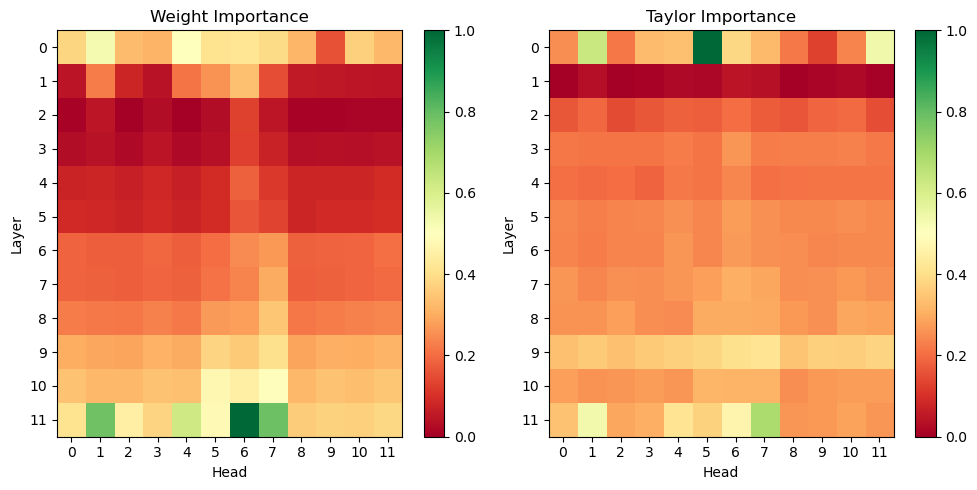


Saved to ./checkpoints/head_importance_heatmaps.png


In [9]:
try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes = axes.flatten()
    
    for idx, (name, importance) in enumerate(importance_dict.items()):
        ax = axes[idx]
        im = ax.imshow(importance.detach().cpu().numpy(), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax.set_xlabel('Head')
        ax.set_ylabel('Layer')
        ax.set_title(f'{name.capitalize()} Importance')
        ax.set_xticks(range(N_HEADS))
        ax.set_yticks(range(N_LAYERS))
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    os.makedirs('./checkpoints', exist_ok=True)
    plt.savefig('./checkpoints/head_importance_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved to ./checkpoints/head_importance_heatmaps.png")
    
except ImportError:
    print("Matplotlib not available")

## 5. EMP Head Pruning Implementation

EMP automatically determines how many heads to keep:
- `N_eff = 1 / Σ(ω_h²)` where `ω_h = |I_h| / Σ|I_j|`
- Keep `r = floor(β × N_eff)` heads

In [10]:
def compute_neff_for_heads(importance: torch.Tensor) -> float:
    """
    Compute N_eff (effective number of heads) using EMP formula.
    
    N_eff = 1 / Σ(ω_h²)  where ω_h = |I_h| / Σ|I_j|
    
    Args:
        importance: (n_layers, n_heads) or flattened importance scores
    
    Returns:
        N_eff: effective number of heads (1 to n_total_heads)
    """
    flat = importance.flatten()
    
    # L1 normalize absolute values
    abs_importance = torch.abs(flat)
    omega = abs_importance / (abs_importance.sum() + 1e-10)
    
    # N_eff = 1 / sum(omega^2)
    neff = 1.0 / (torch.sum(omega ** 2) + 1e-10)
    
    return neff.item()


def create_head_mask_emp(
    importance: torch.Tensor,
    beta: float = 1.0
) -> Tuple[torch.Tensor, dict]:
    """
    Create head mask using EMP criterion.
    
    EMP automatically determines how many heads to keep based on
    the concentration of importance scores.
    
    Algorithm:
        1. ω_h = |I_h| / Σ|I_j|           (L1 normalize)
        2. N_eff = 1 / Σ(ω_h²)            (effective number of heads)
        3. r = floor(β × N_eff)           (number to keep)
        4. Keep top r heads by importance
    
    Args:
        importance: (n_layers, n_heads) importance scores
        beta: scaling factor for N_eff (default 1.0)
              beta < 1: more aggressive pruning
              beta > 1: less aggressive pruning
    
    Returns:
        mask: (n_layers, n_heads) with 1 for kept heads, 0 for pruned
        stats: dict with N_eff, r, prune_ratio
    """
    n_total = importance.numel()
    
    # Compute N_eff
    neff = compute_neff_for_heads(importance)
    
    # Number of heads to keep
    r = max(1, int(beta * neff))  # At least keep 1 head
    r = min(r, n_total)           # Can't keep more than total
    
    # Find threshold: keep top r heads by importance
    flat_importance = importance.flatten()
    sorted_importance, _ = torch.sort(flat_importance, descending=True)
    threshold = sorted_importance[r - 1].item()
    
    # Create mask
    mask = (importance >= threshold).float()
    
    # Handle ties: if more heads than r are above threshold, keep exactly r
    if mask.sum() > r:
        # Get indices sorted by importance
        flat_indices = torch.argsort(flat_importance, descending=True)
        mask = torch.zeros_like(importance)
        for i in range(r):
            idx = flat_indices[i].item()
            layer = idx // N_HEADS
            head = idx % N_HEADS
            mask[layer, head] = 1.0
    
    n_kept = int(mask.sum())
    n_pruned = n_total - n_kept
    
    stats = {
        'n_eff': neff,
        'beta': beta,
        'r_keep': r,
        'n_kept': n_kept,
        'n_pruned': n_pruned,
        'prune_ratio': n_pruned / n_total,
    }
    
    return mask, stats


# Demo: Show N_eff for each importance criterion
print("="*70)
print("EMP Analysis: Effective Number of Heads (N_eff)")
print("="*70)
print(f"Total heads: {N_LAYERS * N_HEADS}")
print()

for name, importance in [('taylor', taylor_importance), 
                          ('weight', weight_importance),
                          #('entropy', entropy_importance),
                          #('combined', importance_dict['combined'])
                        ]:
    neff = compute_neff_for_heads(importance)
    print(f"{name:12s}: N_eff = {neff:6.2f} / {N_LAYERS * N_HEADS} "
          f"({neff / (N_LAYERS * N_HEADS) * 100:5.1f}% effective)")

print()
print("Interpretation:")
print("  - N_eff close to total → importance evenly distributed → less pruning")
print("  - N_eff << total → importance concentrated → more pruning possible")

EMP Analysis: Effective Number of Heads (N_eff)
Total heads: 144

taylor      : N_eff = 141.44 / 144 ( 98.2% effective)
weight      : N_eff = 134.01 / 144 ( 93.1% effective)

Interpretation:
  - N_eff close to total → importance evenly distributed → less pruning
  - N_eff << total → importance concentrated → more pruning possible


In [11]:
def apply_head_mask_to_model(model, head_mask: torch.Tensor):
    """
    Apply head mask by zeroing out the output projection weights of pruned heads.
    
    This is a "soft" pruning - weights are zeroed but still exist.
    For "hard" pruning, you'd actually remove the weights.
    
    Args:
        model: GPT-2 model (will be modified in-place)
        head_mask: (n_layers, n_heads) binary mask
    """
    with torch.no_grad():
        for layer_idx in range(N_LAYERS):
            attn = model.transformer.h[layer_idx].attn
            
            for head_idx in range(N_HEADS):
                if head_mask[layer_idx, head_idx] == 0:
                    # Zero out this head's output projection
                    start = head_idx * HEAD_DIM
                    end = (head_idx + 1) * HEAD_DIM
                    
                    # c_proj: output projection (n_embd, n_embd)
                    attn.c_proj.weight[:, start:end] = 0
                    
                    # Also zero the corresponding part of c_attn (QKV projection)
                    # c_attn produces [Q, K, V] concatenated
                    # Each is (n_embd,), total (3*n_embd,)
                    # Head h's Q is at [h*head_dim : (h+1)*head_dim]
                    # Head h's K is at [n_embd + h*head_dim : n_embd + (h+1)*head_dim]
                    # Head h's V is at [2*n_embd + h*head_dim : 2*n_embd + (h+1)*head_dim]
                    n_embd = config.n_embd
                    attn.c_attn.weight[:, start:end] = 0  # Q
                    attn.c_attn.weight[:, n_embd + start:n_embd + end] = 0  # K
                    attn.c_attn.weight[:, 2*n_embd + start:2*n_embd + end] = 0  # V


def get_pruned_model(model, head_mask: torch.Tensor):
    """
    Create a pruned copy of the model.
    """
    pruned_model = copy.deepcopy(model)
    apply_head_mask_to_model(pruned_model, head_mask)
    return pruned_model

## 6. Evaluation

In [12]:
@torch.no_grad()
def evaluate_perplexity(model, batches: List[torch.Tensor], max_batches: int = None) -> float:
    """Evaluate perplexity on batches."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    
    n_batches = len(batches) if max_batches is None else min(max_batches, len(batches))
    
    for i, batch in enumerate(batches[:n_batches]):
        batch = batch.to(device)
        outputs = model(batch, labels=batch)
        total_loss += outputs.loss.item() * batch.numel()
        total_tokens += batch.numel()
        
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{n_batches}", end='\r')
    
    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)

# Baseline evaluation
print("Evaluating baseline (no pruning)...")
baseline_ppl = evaluate_perplexity(model, test_batches)
print(f"\nBaseline Perplexity: {baseline_ppl:.2f}")

Evaluating baseline (no pruning)...
  120/139
Baseline Perplexity: 34.86


## 7. EMP Pruning Experiments

Test different β values:
- `β < 1`: Aggressive pruning (keep fewer than N_eff heads)
- `β = 1`: Keep exactly N_eff heads  
- `β > 1`: Conservative pruning (keep more than N_eff heads)

In [13]:
def run_emp_pruning_experiment(
    model,
    importance: torch.Tensor,
    importance_name: str,
    beta_values: List[float],
    test_batches: List[torch.Tensor],
    baseline_ppl: float
) -> List[Dict]:
    """
    Run EMP-based pruning experiments for different beta values.
    
    EMP determines pruning automatically:
        N_eff = 1 / Σ(ω_h²)  where ω_h = |I_h| / Σ|I_j|
        Keep r = floor(β × N_eff) heads
    """
    results = []
    
    for beta in beta_values:
        # Create mask using EMP
        head_mask, emp_stats = create_head_mask_emp(importance, beta)
        
        # Create pruned model
        pruned_model = get_pruned_model(model, head_mask)
        
        # Evaluate
        ppl = evaluate_perplexity(pruned_model, test_batches)
        
        result = {
            'criterion': importance_name,
            'beta': beta,
            'n_eff': emp_stats['n_eff'],
            'n_kept': emp_stats['n_kept'],
            'n_pruned': emp_stats['n_pruned'],
            'prune_ratio': emp_stats['prune_ratio'],
            'ppl': ppl,
            'delta_ppl': ppl - baseline_ppl,
            'delta_ppl_pct': (ppl - baseline_ppl) / baseline_ppl * 100,
        }
        results.append(result)
        
        print(f"  {importance_name:10s} | β={beta:4.2f} | N_eff={emp_stats['n_eff']:5.1f} | "
              f"Keep {emp_stats['n_kept']:3d}/{N_LAYERS*N_HEADS} ({100-emp_stats['prune_ratio']*100:4.1f}%) | "
              f"PPL {ppl:7.2f} | dPPL {ppl - baseline_ppl:+6.2f} ({(ppl - baseline_ppl) / baseline_ppl * 100:+5.1f}%)")
        
        # Clean up
        del pruned_model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return results

In [14]:
# Run EMP experiments with different beta values
# beta < 1: more aggressive pruning (keep fewer than N_eff heads)
# beta = 1: keep exactly N_eff heads
# beta > 1: less aggressive pruning (keep more than N_eff heads)

beta_values = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

all_results = []

# Add baseline
all_results.append({
    'criterion': 'baseline',
    'beta': float('inf'),
    'n_eff': N_LAYERS * N_HEADS,
    'n_kept': N_LAYERS * N_HEADS,
    'n_pruned': 0,
    'prune_ratio': 0.0,
    'ppl': baseline_ppl,
    'delta_ppl': 0,
    'delta_ppl_pct': 0,
})

print("="*110)
print("EMP HEAD PRUNING EXPERIMENTS")
print("="*110)
print(f"Baseline PPL: {baseline_ppl:.2f}")
print(f"Total heads: {N_LAYERS * N_HEADS}")
print()
print("EMP Formula: Keep r = floor(β × N_eff) heads, where N_eff = 1/Σ(ω_h²)")
print("="*110)

# Test each importance criterion with EMP
criteria = [
    ('taylor', taylor_importance),
    ('weight', weight_importance),
    #('entropy', entropy_importance),
    #('combined', importance_dict['combined']),
]

for name, importance in criteria:
    neff = compute_neff_for_heads(importance)
    print(f"\n--- Criterion: {name.upper()} (N_eff = {neff:.2f}) ---")
    results = run_emp_pruning_experiment(
        model, importance, name, beta_values, test_batches, baseline_ppl
    )
    all_results.extend(results)

EMP HEAD PRUNING EXPERIMENTS
Baseline PPL: 34.86
Total heads: 144

EMP Formula: Keep r = floor(β × N_eff) heads, where N_eff = 1/Σ(ω_h²)

--- Criterion: TAYLOR (N_eff = 141.44) ---
  taylor     | β=0.25 | N_eff=141.4 | Keep  35/144 (24.3%) | PPL  554.45 | dPPL +519.58 (+1490.3%)
  taylor     | β=0.50 | N_eff=141.4 | Keep  70/144 (48.6%) | PPL  255.00 | dPPL +220.14 (+631.4%)
  taylor     | β=0.75 | N_eff=141.4 | Keep 106/144 (73.6%) | PPL   94.72 | dPPL +59.85 (+171.7%)
  taylor     | β=1.00 | N_eff=141.4 | Keep 141/144 (97.9%) | PPL   35.20 | dPPL  +0.34 ( +1.0%)
  taylor     | β=1.25 | N_eff=141.4 | Keep 144/144 (100.0%) | PPL   34.86 | dPPL  +0.00 ( +0.0%)
  taylor     | β=1.50 | N_eff=141.4 | Keep 144/144 (100.0%) | PPL   34.86 | dPPL  +0.00 ( +0.0%)
  taylor     | β=2.00 | N_eff=141.4 | Keep 144/144 (100.0%) | PPL   34.86 | dPPL  +0.00 ( +0.0%)

--- Criterion: WEIGHT (N_eff = 134.01) ---
  weight     | β=0.25 | N_eff=134.0 | Keep  33/144 (22.9%) | PPL  881.12 | dPPL +846.26 (+2427

## 8. Analysis

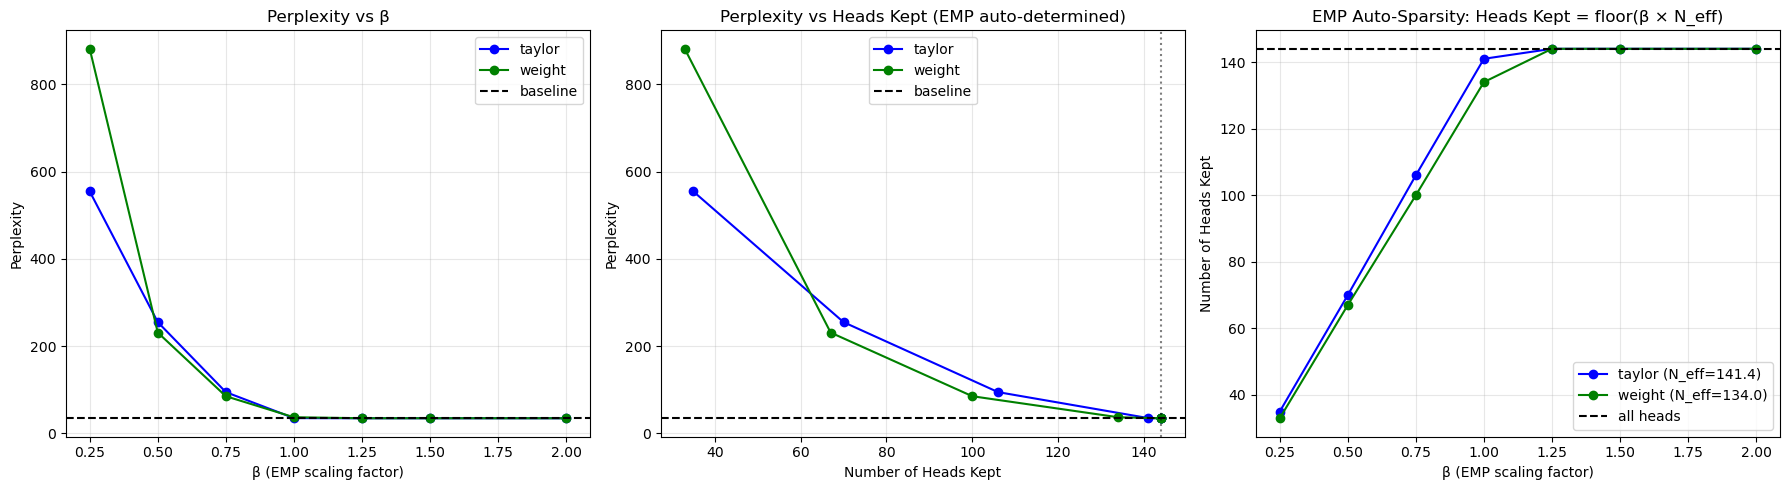

In [15]:
try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Group results by criterion
    criteria_results = {}
    for r in all_results:
        c = r['criterion']
        if c not in criteria_results:
            criteria_results[c] = []
        criteria_results[c].append(r)
    
    colors = {
        'taylor': 'blue',
        'weight': 'green',
        #'entropy': 'orange',
        #'combined': 'red',
        'baseline': 'black',
    }
    
    # Plot 1: PPL vs Beta
    ax = axes[0]
    for criterion, results in criteria_results.items():
        if criterion == 'baseline':
            continue
        betas = [r['beta'] for r in results]
        ppls = [r['ppl'] for r in results]
        ax.plot(betas, ppls, 'o-', label=criterion, color=colors.get(criterion, 'purple'))
    
    ax.axhline(y=baseline_ppl, color='black', linestyle='--', label='baseline')
    ax.set_xlabel('β (EMP scaling factor)')
    ax.set_ylabel('Perplexity')
    ax.set_title('Perplexity vs β')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: PPL vs Heads Kept
    ax = axes[1]
    for criterion, results in criteria_results.items():
        if criterion == 'baseline':
            continue
        n_kept = [r['n_kept'] for r in results]
        ppls = [r['ppl'] for r in results]
        ax.plot(n_kept, ppls, 'o-', label=criterion, color=colors.get(criterion, 'purple'))
    
    ax.axhline(y=baseline_ppl, color='black', linestyle='--', label='baseline')
    ax.axvline(x=N_LAYERS * N_HEADS, color='black', linestyle=':', alpha=0.5)
    ax.set_xlabel('Number of Heads Kept')
    ax.set_ylabel('Perplexity')
    ax.set_title('Perplexity vs Heads Kept (EMP auto-determined)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Heads Kept vs Beta (shows how EMP determines sparsity)
    ax = axes[2]
    for criterion, results in criteria_results.items():
        if criterion == 'baseline':
            continue
        betas = [r['beta'] for r in results]
        n_kept = [r['n_kept'] for r in results]
        ax.plot(betas, n_kept, 'o-', label=f"{criterion} (N_eff={results[0]['n_eff']:.1f})", 
                color=colors.get(criterion, 'purple'))
    
    ax.axhline(y=N_LAYERS * N_HEADS, color='black', linestyle='--', label='all heads')
    ax.set_xlabel('β (EMP scaling factor)')
    ax.set_ylabel('Number of Heads Kept')
    ax.set_title('EMP Auto-Sparsity: Heads Kept = floor(β × N_eff)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    os.makedirs('./checkpoints', exist_ok=True)
    plt.savefig('./checkpoints/head_pruning_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except ImportError:
    print("Matplotlib not available")

In [16]:
# Find best criterion at β=1.0 (keep exactly N_eff heads)
print("\n" + "="*100)
print("BEST CRITERION AT EACH β VALUE")
print("="*100)

for beta in beta_values:
    beta_results = [r for r in all_results if r.get('beta') == beta and r['criterion'] != 'baseline']
    if beta_results:
        best = min(beta_results, key=lambda x: x['ppl'])
        print(f"β={beta:4.2f}: Best = {best['criterion']:10s} | "
              f"Keep {best['n_kept']:3d} heads | PPL {best['ppl']:6.2f} | "
              f"dPPL {best['delta_ppl']:+5.2f}")


BEST CRITERION AT EACH β VALUE
β=0.25: Best = taylor     | Keep  35 heads | PPL 554.45 | dPPL +519.58
β=0.50: Best = weight     | Keep  67 heads | PPL 231.09 | dPPL +196.23
β=0.75: Best = weight     | Keep 100 heads | PPL  85.30 | dPPL +50.44
β=1.00: Best = taylor     | Keep 141 heads | PPL  35.20 | dPPL +0.34
β=1.25: Best = taylor     | Keep 144 heads | PPL  34.86 | dPPL +0.00
β=1.50: Best = taylor     | Keep 144 heads | PPL  34.86 | dPPL +0.00
β=2.00: Best = taylor     | Keep 144 heads | PPL  34.86 | dPPL +0.00


In [17]:
# Analyze which heads are pruned with Taylor importance at β=1.0
print("\n" + "="*80)
print("HEADS PRUNED WITH TAYLOR IMPORTANCE (β=1.0, EMP auto-sparsity)")
print("="*80)

head_mask_emp, emp_stats = create_head_mask_emp(taylor_importance, beta=1.0)

print(f"\nEMP Statistics:")
print(f"  N_eff = {emp_stats['n_eff']:.2f}")
print(f"  β = {emp_stats['beta']}")
print(f"  r = floor(β × N_eff) = {emp_stats['r_keep']}")
print(f"  Heads kept: {emp_stats['n_kept']} / {N_LAYERS * N_HEADS}")
print(f"  Auto prune ratio: {emp_stats['prune_ratio']*100:.1f}%")

print("\nPruned heads (layer, head):")
pruned_heads = []
for layer_idx in range(N_LAYERS):
    for head_idx in range(N_HEADS):
        if head_mask_emp[layer_idx, head_idx] == 0:
            pruned_heads.append((layer_idx, head_idx))
            print(f"  Layer {layer_idx:2d}, Head {head_idx:2d} (importance: {taylor_importance[layer_idx, head_idx]:.4f})")

# Show pruning distribution by layer
print("\nPruned heads per layer:")
for layer_idx in range(N_LAYERS):
    n_pruned_layer = int((1 - head_mask_emp[layer_idx]).sum())
    kept_str = ''.join(['●' if head_mask_emp[layer_idx, h] == 1 else '○' for h in range(N_HEADS)])
    print(f"  Layer {layer_idx:2d}: {kept_str}  ({N_HEADS - n_pruned_layer}/{N_HEADS} kept)")


HEADS PRUNED WITH TAYLOR IMPORTANCE (β=1.0, EMP auto-sparsity)

EMP Statistics:
  N_eff = 141.44
  β = 1.0
  r = floor(β × N_eff) = 141
  Heads kept: 141 / 144
  Auto prune ratio: 2.1%

Pruned heads (layer, head):
  Layer  1, Head  0 (importance: 0.0446)
  Layer  1, Head  2 (importance: 0.0447)
  Layer  1, Head  8 (importance: 0.0448)

Pruned heads per layer:
  Layer  0: ●●●●●●●●●●●●  (12/12 kept)
  Layer  1: ○●○●●●●●○●●●  (9/12 kept)
  Layer  2: ●●●●●●●●●●●●  (12/12 kept)
  Layer  3: ●●●●●●●●●●●●  (12/12 kept)
  Layer  4: ●●●●●●●●●●●●  (12/12 kept)
  Layer  5: ●●●●●●●●●●●●  (12/12 kept)
  Layer  6: ●●●●●●●●●●●●  (12/12 kept)
  Layer  7: ●●●●●●●●●●●●  (12/12 kept)
  Layer  8: ●●●●●●●●●●●●  (12/12 kept)
  Layer  9: ●●●●●●●●●●●●  (12/12 kept)
  Layer 10: ●●●●●●●●●●●●  (12/12 kept)
  Layer 11: ●●●●●●●●●●●●  (12/12 kept)


In [18]:
# Save results
os.makedirs('./checkpoints', exist_ok=True)

# Compute N_eff for each criterion
neff_scores = {
    'taylor': compute_neff_for_heads(taylor_importance),
    'weight': compute_neff_for_heads(weight_importance),
    #'entropy': compute_neff_for_heads(entropy_importance),
    #'combined': compute_neff_for_heads(importance_dict['combined']),
}

results_to_save = {
    'model': MODEL_NAME,
    'baseline_ppl': baseline_ppl,
    'n_layers': N_LAYERS,
    'n_heads': N_HEADS,
    'total_heads': N_LAYERS * N_HEADS,
    'emp_neff_scores': neff_scores,
    'beta_values': beta_values,
    'experiments': all_results,
    'importance_scores': {
        'taylor': taylor_importance.detach().cpu().tolist(),
        'weight': weight_importance.detach().cpu().tolist(),
        #'entropy': entropy_importance.detach().cpu().tolist(),
        #'combined': importance_dict['combined'].detach().cpu().tolist(),
    }
}

with open('./checkpoints/head_pruning_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("Results saved to ./checkpoints/head_pruning_results.json")

Results saved to ./checkpoints/head_pruning_results.json


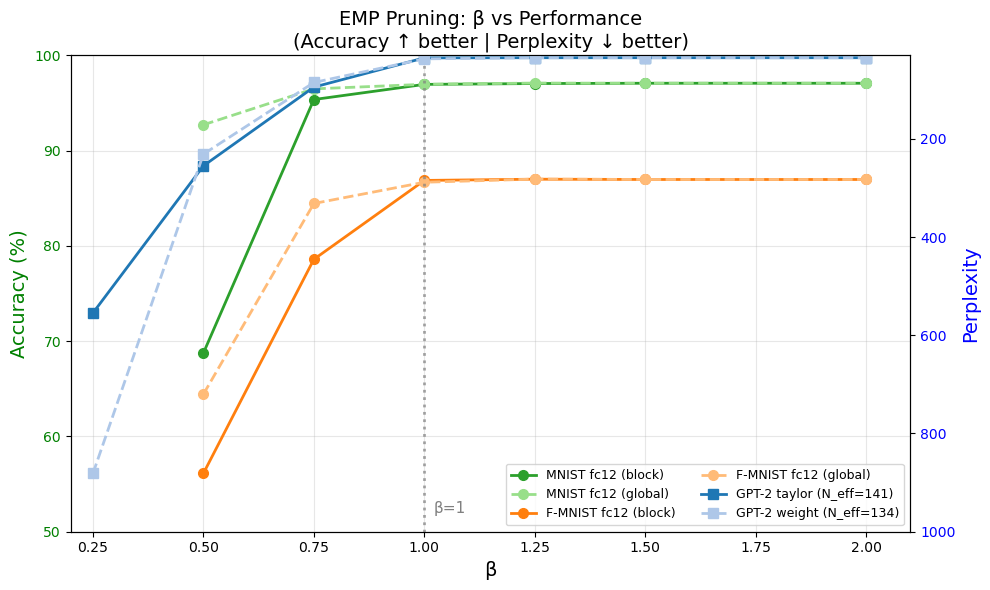

In [26]:
# ============================================================================
# EMP Comparison: Single Figure with Dual Y-Axis
# Left Y: Accuracy (%) for MLP models
# Right Y: Perplexity (inverted, lower=better=top) for GPT-2
# X: Beta
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# 1. GPT-2 Head Pruning Results
# -----------------------------------------------------------------------------
gpt2_rows = []
for r in all_results:
    if r['criterion'] == 'baseline':
        continue
    gpt2_rows.append({
        'Criterion': r['criterion'],
        'Beta': r['beta'],
        'PPL': r['ppl'],
        'N_eff': r['n_eff'],
    })

gpt2_df = pd.DataFrame(gpt2_rows)

# -----------------------------------------------------------------------------
# 2. MLP Weight Pruning Results
# -----------------------------------------------------------------------------
mlp_rows = []

def add_mlp_rows(dataset, baseline, entries):
    for e in entries:
        mlp_rows.append({'Dataset': dataset, 'Mode': 'block', 'Beta': e['beta'], 
                         'Acc': e['block_acc'], 'Baseline': baseline})
        mlp_rows.append({'Dataset': dataset, 'Mode': 'global', 'Beta': e['beta'],
                         'Acc': e['global_acc'], 'Baseline': baseline})

add_mlp_rows("MNIST", 97.07, [
    {"beta":0.5, "block_acc":68.76, "global_acc":92.71},
    {"beta":0.75, "block_acc":95.36, "global_acc":96.48},
    {"beta":1.0, "block_acc":96.95, "global_acc":96.96},
    {"beta":1.25, "block_acc":97.04, "global_acc":97.09},
    {"beta":1.5, "block_acc":97.07, "global_acc":97.07},
    {"beta":2.0, "block_acc":97.07, "global_acc":97.07},
])

add_mlp_rows("F-MNIST", 86.97, [
    {"beta":0.5, "block_acc":56.13, "global_acc":64.44},
    {"beta":0.75, "block_acc":78.59, "global_acc":84.45},
    {"beta":1.0, "block_acc":86.87, "global_acc":86.68},
    {"beta":1.25, "block_acc":87.00, "global_acc":87.01},
    {"beta":1.5, "block_acc":86.97, "global_acc":86.97},
    {"beta":2.0, "block_acc":86.97, "global_acc":86.97},
])

mlp_df = pd.DataFrame(mlp_rows)

# -----------------------------------------------------------------------------
# 3. Create Dual-Axis Figure
# -----------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Colors and markers
colors_mlp = {
    ('MNIST', 'block'): '#2ca02c',
    ('MNIST', 'global'): '#98df8a',
    ('F-MNIST', 'block'): '#ff7f0e',
    ('F-MNIST', 'global'): '#ffbb78',
}
colors_gpt2 = {
    'taylor': '#1f77b4',
    'weight': '#aec7e8',
}
linestyles = {'block': '-', 'global': '--'}

# --- Left Y-axis: Accuracy (MLP) ---
ax1.set_xlabel('β', fontsize=14)
ax1.set_ylabel('Accuracy (%)', fontsize=14, color='green')
ax1.tick_params(axis='y', labelcolor='green')

for dataset in ['MNIST', 'F-MNIST']:
    for mode in ['block', 'global']:
        subset = mlp_df[(mlp_df['Dataset'] == dataset) & (mlp_df['Mode'] == mode)].sort_values('Beta')
        color = colors_mlp[(dataset, mode)]
        label = '{} fc12 ({})'.format(dataset, mode)
        ax1.plot(subset['Beta'], subset['Acc'], 
                 marker='o', linestyle=linestyles[mode], color=color,
                 label=label, linewidth=2, markersize=7)

ax1.set_ylim([50, 100])
ax1.set_xlim([0.2, 2.1])

# --- Right Y-axis: Perplexity (GPT-2, inverted) ---
ax2 = ax1.twinx()
ax2.set_ylabel('Perplexity', fontsize=14, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

for criterion in ['taylor', 'weight']:
    subset = gpt2_df[gpt2_df['Criterion'] == criterion].sort_values('Beta')
    if len(subset) == 0:
        continue
    neff_val = subset['N_eff'].iloc[0]
    color = colors_gpt2[criterion]
    ls = '-' if criterion == 'taylor' else '--'
    label = 'GPT-2 {} (N_eff={:.0f})'.format(criterion, neff_val)
    ax2.plot(subset['Beta'], subset['PPL'], 
             marker='s', linestyle=ls, color=color,
             label=label, linewidth=2, markersize=7)

# Invert right y-axis so lower perplexity is at top (better = up)
ax2.invert_yaxis()
ax2.set_ylim([1000, 30])  # From 1000 (bottom, bad) to 30 (top, good)

# --- Vertical line at β=1.0 ---
ax1.axvline(x=1.0, color='gray', linestyle=':', alpha=0.7, linewidth=2)
ax1.text(1.02, 52, 'β=1', fontsize=11, color='gray')

# --- Legends ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9, ncol=2)

# --- Title and grid ---
ax1.set_title('EMP Pruning: β vs Performance\n(Accuracy ↑ better | Perplexity ↓ better)', fontsize=14)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./checkpoints/emp_beta_vs_performance_dual.pdf', dpi=200, bbox_inches='tight')
plt.savefig('./checkpoints/emp_beta_vs_performance_dual.png', dpi=200, bbox_inches='tight')
plt.show()